# GumH
Following is the workflow for studying GumH, from Boltz predictions of the different states to the simulations of each complex and the analysis

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")
import MDAnalysis as mda
from MDAnalysis.analysis import rms
from MDAnalysis.analysis import align
import json

## Boltz prediction free


In [4]:
ptm = []
plddt = []
pde = []
for i in range(20):
    with open(f"confidence_GumH_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        ptm.append(data['ptm'])
        plddt.append(data['complex_plddt'])
        pde.append(data['complex_pde'])
        
        

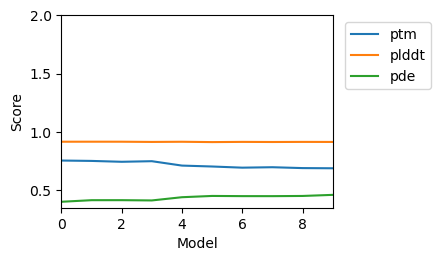

In [5]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(ptm, label = 'ptm')
plt.plot(plddt, label = 'plddt')
plt.plot(pde, label = 'pde')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)
plt.xlim(0,9)
plt.ylim(0.35,2.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_free.png", dpi=600, bbox_inches="tight")

In [33]:
import gemmi
def idx(f):
    m = re.search(r"GumH_model_(\d+)\.cif$", f)
    return int(m.group(1)) if m else None

cifs = [(idx(f), f) for f in glob.glob("GumH_model_*.cif")]
cifs = sorted([x for x in cifs if x[0] is not None and 0 <= x[0] <= 9], key=lambda x: x[0])

for i, f in cifs:
    st = gemmi.read_structure(f)
    st.write_pdb(f"model_{i}.pdb")


Convertiti: ['model_0.pdb', 'model_1.pdb', 'model_2.pdb', 'model_3.pdb', 'model_4.pdb', 'model_5.pdb', 'model_6.pdb', 'model_7.pdb', 'model_8.pdb', 'model_9.pdb']


In [34]:
from MDAnalysis.analysis.distances import dist
pdbs = sorted(glob.glob("model_[0-9].pdb"))  # prende 0..9
assert len(pdbs) == 10, f"Trovati {len(pdbs)} pdb (attesi 10)"

# Selezioni: cambia i resid!
sel1 = "name CA and resid 93"
sel2 = "name CA and resid 283"

distances = []

for f in pdbs:
    u = mda.Universe(f)
    a = u.select_atoms(sel1)
    b = u.select_atoms(sel2)

    if len(a) != 1 or len(b) != 1:
        raise ValueError(f"{f}: selezione non univoca (a={len(a)}, b={len(b)})")

    d = np.linalg.norm(a.positions[0] - b.positions[0])
    distances.append(d)


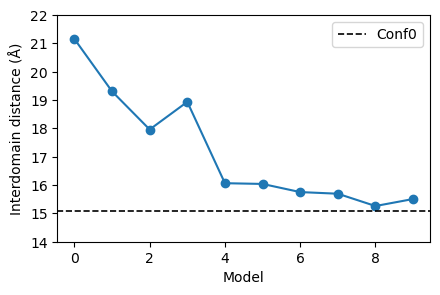

In [39]:
plt.figure(figsize=(4.5, 3.0))
plt.plot(range(10), distances, marker="o")
plt.axhline(15.1, linestyle="--", linewidth=1.2, label=f"Conf0", color='black')

plt.xlabel("Model")
plt.ylabel("Interdomain distance (Å)")
plt.legend()
plt.tight_layout()
plt.ylim(14,22)
plt.savefig("interomdain_prediction_free_gumH.png", dpi=600)
plt.show()

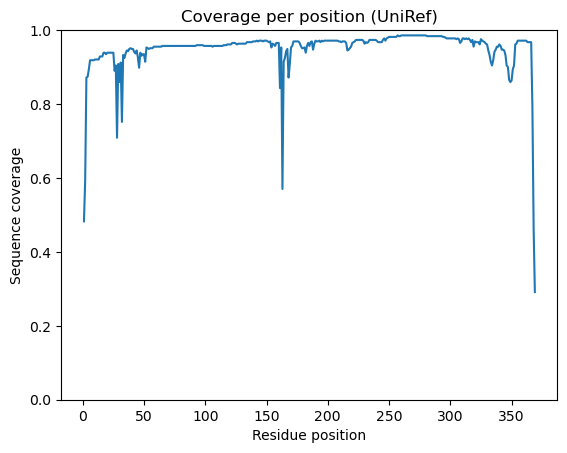

Numero sequenze: 491
Coverage media: 0.9503032912202849


In [7]:
import numpy as np
import matplotlib.pyplot as plt


seqs = []
with open("uniref.a3m") as f:
    seq = ""
    for line in f:
        if line.startswith(">"):
            if seq:
                seqs.append(seq)
            seq = ""
        else:
            seq += line.strip()
    if seq:
        seqs.append(seq)


aligned = [''.join(c for c in s if not c.islower()) for s in seqs]

L = len(aligned[0])
N = len(aligned)


coverage = np.zeros(L)
for i in range(L):
    non_gap = sum(1 for s in aligned if s[i] != '-')
    coverage[i] = non_gap / N


plt.figure()
plt.plot(range(1, L+1), coverage)
plt.ylim(0,1)
plt.xlabel("Residue position")
plt.ylabel("Sequence coverage")
plt.title("Coverage per position (UniRef)")
plt.savefig("coverage_gumh.png", dpi=600)
plt.show()



## Boltz prediction product        

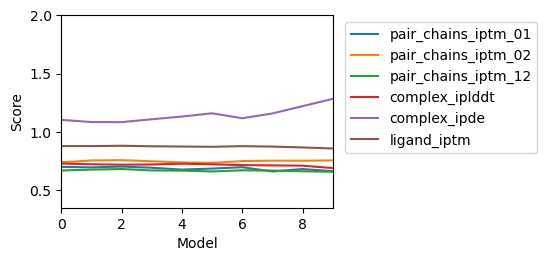

In [8]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(iptm02,label= 'pair_chains_iptm_02')
plt.plot(iptm12, label = 'pair_chains_iptm_12')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.xlim(0,9)
plt.ylim(0.35,2.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_prod.png", dpi=600, bbox_inches="tight")

## Boltz prediction full complex

In [10]:
iptm01 = []
iptm02 = []
iptm12 = []
ciplddt = []
cipde = []
liptm = []
for i in range(10):
    with open(f"confidence_GumH_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        iptm01.append(data['pair_chains_iptm']['0']['1'])
        iptm02.append(data['pair_chains_iptm']['0']['2'])
        iptm12.append(data['pair_chains_iptm']['1']['2'])
        ciplddt.append(data['complex_iplddt'])
        cipde.append(data['complex_ipde'])
        liptm.append(data['ligand_iptm'])
        
        

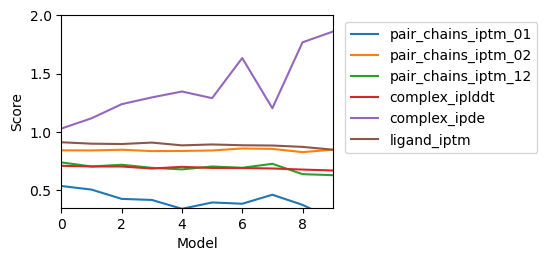

In [11]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(iptm02,label= 'pair_chains_iptm_02')
plt.plot(iptm12, label = 'pair_chains_iptm_12')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)

plt.xlim(0,9)
plt.ylim(0.35,2.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_full.png", dpi=600, bbox_inches="tight")

## Boltz prediction donor

In [13]:
iptm01 = []
ciplddt = []
cipde = []
liptm = []
for i in range(10):
    with open(f"confidence_GumH_model_{i}.json", "r", encoding="utf-8") as f:
        data = json.load(f)
        iptm01.append(data['pair_chains_iptm']['0']['1'])
        ciplddt.append(data['complex_iplddt'])
        cipde.append(data['complex_ipde'])
        liptm.append(data['ligand_iptm'])
        

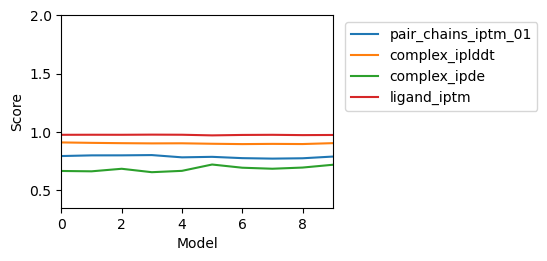

In [14]:
plt.figure(figsize=(3.5, 2.5))
plt.plot(iptm01, label = 'pair_chains_iptm_01')
plt.plot(ciplddt, label = 'complex_iplddt')
plt.plot(cipde, label = 'complex_ipde')
plt.plot(liptm, label = 'ligand_iptm')
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0)
)
plt.xlim(0,9)
plt.ylim(0.35,2.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.savefig("metrics_plot_donor.png", dpi=600, bbox_inches="tight")

In [41]:
import gemmi
def idx(f):
    m = re.search(r"GumH_model_(\d+)\.cif$", f)
    return int(m.group(1)) if m else None

cifs = [(idx(f), f) for f in glob.glob("GumH_model_*.cif")]
cifs = sorted([x for x in cifs if x[0] is not None and 0 <= x[0] <= 9], key=lambda x: x[0])

for i, f in cifs:
    st = gemmi.read_structure(f)
    st.write_pdb(f"model_{i}.pdb")

Convertiti: ['model_0.pdb', 'model_1.pdb', 'model_2.pdb', 'model_3.pdb', 'model_4.pdb', 'model_5.pdb', 'model_6.pdb', 'model_7.pdb', 'model_8.pdb', 'model_9.pdb']


In [42]:
from MDAnalysis.analysis.distances import dist
pdbs = sorted(glob.glob("model_[0-9].pdb"))  # prende 0..9
assert len(pdbs) == 10, f"Trovati {len(pdbs)} pdb (attesi 10)"


sel1 = "name CA and resid 93"
sel2 = "name CA and resid 283"

distances = []

for f in pdbs:
    u = mda.Universe(f)
    a = u.select_atoms(sel1)
    b = u.select_atoms(sel2)

    if len(a) != 1 or len(b) != 1:
        raise ValueError(f"{f}: selezione non univoca (a={len(a)}, b={len(b)})")

    d = np.linalg.norm(a.positions[0] - b.positions[0])
    distances.append(d)


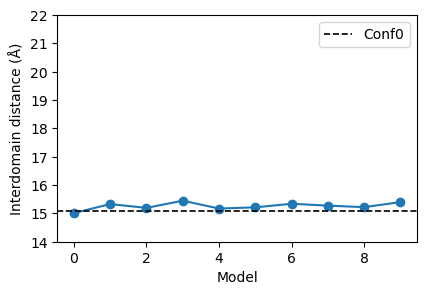

In [44]:
plt.figure(figsize=(4.5, 3.0))
plt.plot(range(10), distances, marker="o")
plt.axhline(15.1, linestyle="--", linewidth=1.2, label=f"Conf0", color='black')

plt.xlabel("Model")
plt.ylabel("Interdomain distance (Å)")
plt.legend()
plt.tight_layout()
plt.ylim(14,22)
plt.savefig("interomdain_prediction_donor_gumH.png", dpi=600)
plt.show()

# ANM conf0


In [6]:
from prody import *

In [7]:
gumh=parsePDB('sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [6]:
gumh_anm = exANM('gumh_exanm')
gumh_anm

<exANM: gumh_exanm (0 modes; 0 nodes)>

In [7]:
gumh_ca = gumh.ca
gumh_ca

<Selection: 'ca' from sample_998out (369 atoms)>

In [8]:
gumh_anm.buildMembrane(gumh_ca, membrane_high = 5, membrane_low = -20 , hull= False, lat = 'FCC' )

@> Membrane was built in  1s.


array([[ 18.789     , -24.107     , -35.326     ],
       [ 16.035     , -22.045     , -33.777     ],
       [ 14.954     , -18.369     , -34.071     ],
       ...,
       [-52.60874452,  56.99280656,   4.38406204],
       [-48.22468248,  61.37686861,   4.38406204],
       [-43.84062043,  65.76093065,   4.38406204]])

In [9]:
a =gumh_anm.getMembrane()

In [10]:
writePDB('memb_fcc_2.pdb', a)

'memb_fcc_2.pdb'

In [11]:
gumh_anm.buildHessian(gumh_ca)
gumh_anm.calcModes()

@> layers: [0 1 2 3]
@> max layer: 3
@> layer: 0
@> layer: 1
@> layer: 2
@> layer: 3
@> layer: 3 finished
@> layer: 2 finished
@> layer: 1 finished
@> layer: 0 finished
@> Hessian was built in 22.30s.
@> 20 modes were calculated in 0.29s.


In [12]:
writeNMD('gumh_anm.nmd', gumh_anm, gumh_ca)

'gumh_anm.nmd'

In [13]:
saveModel(gumh_anm)

'gumh_exanm.exanm.npz'

In [8]:
gumh_anm = ANM('gumh_exanm')
gumh_anm

<ANM: gumh_exanm (0 modes; 0 nodes)>

In [10]:
gumh_ca = gumh.ca
gumh_ca

<Selection: 'ca' from sample_998out (369 atoms)>

In [11]:
gumh_anm.buildHessian(gumh_ca)
gumh_anm.calcModes()

@> Hessian was built in 0.12s.
@> 20 modes were calculated in 0.09s.


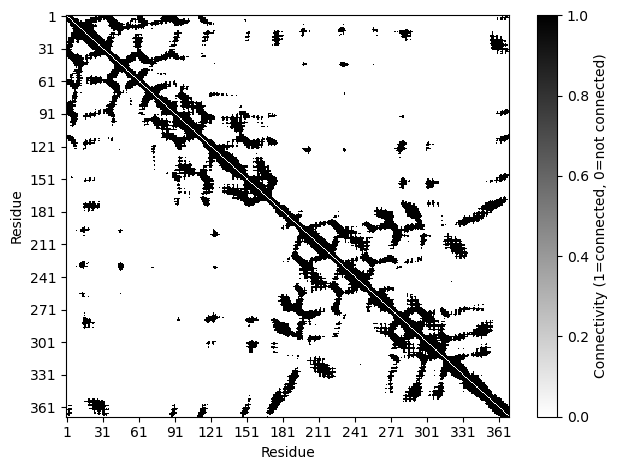

In [12]:
matrix = gumh_anm.getKirchhoff()

N = matrix.shape[0]
start_res = 1
residue_numbers = np.arange(start_res, start_res + N)

mask = np.eye(matrix.shape[0], dtype=bool)
masked_kirchhoff = np.ma.array(matrix, mask=mask)

plt.imshow(-masked_kirchhoff, cmap='gray_r', interpolation='nearest', aspect='auto')
plt.colorbar(label='Connectivity (1=connected, 0=not connected)')

step = 30
ticks = np.arange(0, N, step) 
tick_labels = residue_numbers[ticks]  

plt.xticks(ticks, tick_labels)
plt.yticks(ticks, tick_labels)

plt.xlabel('Residue')
plt.ylabel('Residue')

plt.tight_layout()
plt.savefig(
    "gumh_anm_matrix_closed.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


# ANM model0


In [14]:
from prody import *

In [15]:
gumh=parsePDB('model0out.pdb')

@> 2883 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [13]:
gumh_anm = exANM('gumh_exanm')
gumh_anm

<exANM: gumh_exanm (0 modes; 0 nodes)>

In [14]:
gumh_ca = gumh.ca
gumh_ca

<Selection: 'ca' from model0out (369 atoms)>

In [15]:
gumh_anm.buildMembrane(gumh_ca, membrane_high = 5, membrane_low = -20 , hull= False, lat = 'FCC' )

@> Membrane was built in  1s.


array([[-23.335     , -10.812     , -32.712     ],
       [-22.949     ,  -7.038     , -32.412     ],
       [-19.405     ,  -5.711     , -32.506     ],
       ...,
       [-52.60874452,  56.99280656,   4.38406204],
       [-48.22468248,  61.37686861,   4.38406204],
       [-43.84062043,  65.76093065,   4.38406204]])

In [16]:
a =gumh_anm.getMembrane()

In [17]:
writePDB('memb_fcc_2.pdb', a)

'memb_fcc_2.pdb'

In [18]:
gumh_anm.buildHessian(gumh_ca)
gumh_anm.calcModes()

@> layers: [0 1 2 3]
@> max layer: 3
@> layer: 0
@> layer: 1
@> layer: 2
@> layer: 3
@> layer: 3 finished
@> layer: 2 finished
@> layer: 1 finished
@> layer: 0 finished
@> Hessian was built in 21.44s.
@> 20 modes were calculated in 0.28s.


In [20]:
writeNMD('gumh_anm.nmd', gumh_anm, gumh_ca)

'gumh_anm.nmd'

In [21]:
saveModel(gumh_anm)

'gumh_exanm.exanm.npz'

In [16]:
gumh_anm = ANM('gumh_exanm')
gumh_anm

<ANM: gumh_exanm (0 modes; 0 nodes)>

In [17]:
gumh_ca = gumh.ca
gumh_ca

<Selection: 'ca' from model0out (369 atoms)>

In [18]:
gumh_anm.buildHessian(gumh_ca)
gumh_anm.calcModes()

@> Hessian was built in 0.10s.
@> 20 modes were calculated in 0.10s.


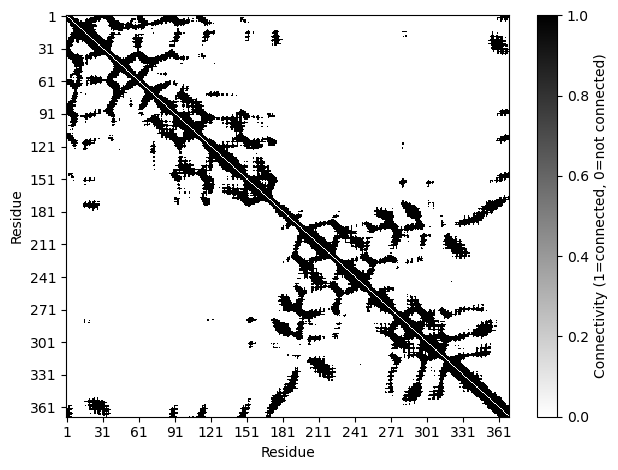

In [19]:
matrix = gumh_anm.getKirchhoff()

N = matrix.shape[0]
start_res = 1
residue_numbers = np.arange(start_res, start_res + N)

mask = np.eye(matrix.shape[0], dtype=bool)
masked_kirchhoff = np.ma.array(matrix, mask=mask)

plt.imshow(-masked_kirchhoff, cmap='gray_r', interpolation='nearest', aspect='auto')
plt.colorbar(label='Connectivity (1=connected, 0=not connected)')

step = 30
ticks = np.arange(0, N, step) 
tick_labels = residue_numbers[ticks]  

plt.xticks(ticks, tick_labels)
plt.yticks(ticks, tick_labels)

plt.xlabel('Residue')
plt.ylabel('Residue')

plt.tight_layout()
plt.savefig(
    "gumh_anm_matrix_closed.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()


## ClustENMD

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [47]:
structure = parsePDB('./rep1/sample_998out_fixed.pdb')
dcd1 = parseDCD('./rep1/ensemble.dcd')
dcd2 = parseDCD('./rep2/ensemble.dcd')
dcd3 = parseDCD('./rep3/ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.08s.
@> DCD file contains 4651 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.02 seconds.
@> 306.94 MB parsed at input rate 152.27 MB/s.
@> 4651 coordinate sets parsed at input rate 2307 frame/s.
@> DCD file contains 4648 coordinate sets for 5760 atoms.
@> DCD file was parsed in 3.72 seconds.
@> 306.74 MB parsed at input rate 82.56 MB/s.
@> 4648 coordinate sets parsed at input rate 1251 frame/s.
@> DCD file contains 4650 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.11 seconds.
@> 306.87 MB parsed at input rate 145.66 MB/s.
@> 4650 coordinate sets parsed at input rate 2207 frame/s.


In [48]:
dcd1.setCoords(structure)
dcd2.setCoords(structure)
dcd3.setCoords(structure)

In [49]:
dcd1.setAtoms(structure.calpha)
dcd2.setAtoms(structure.calpha)
dcd3.setAtoms(structure.calpha)

In [50]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [51]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1] + [frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd2] + [frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd3])  

In [52]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [53]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [55]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [56]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1] + [calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd2] + [calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd3] )

In [60]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

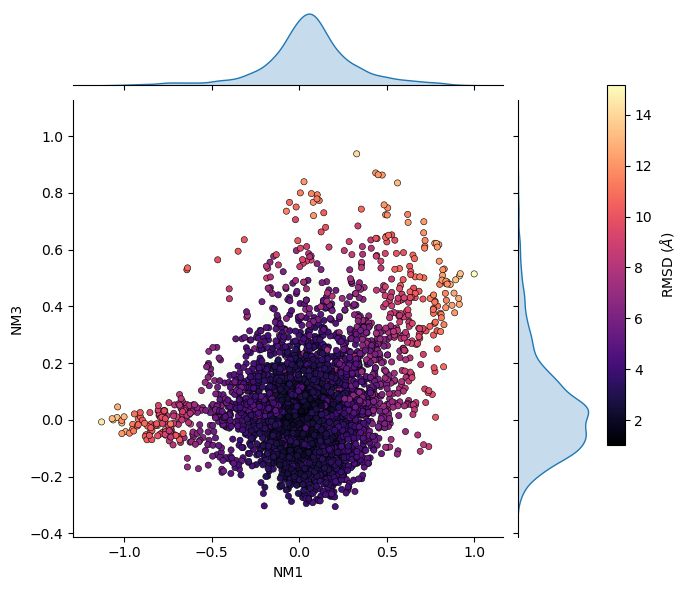

In [59]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)



scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Full complex

### Clamp motion

In [59]:
u = mda.Universe("./ref_vis.pdb", "md_mol.xtc")

In [60]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [61]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

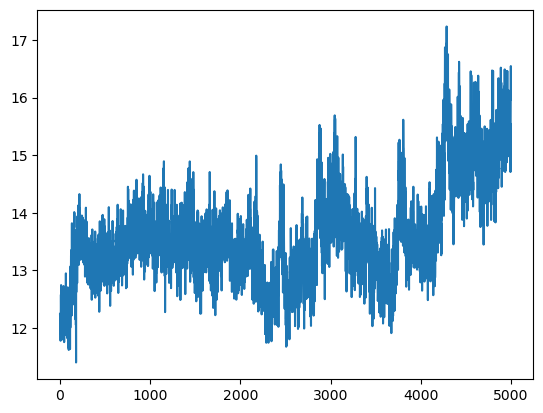

In [62]:
plt.plot(dist)

### ANM projection

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [15]:
structure = parsePDB('./ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.16s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.14 seconds.
@> 330.04 MB parsed at input rate 154.56 MB/s.
@> 5001 coordinate sets parsed at input rate 2342 frame/s.


In [16]:
dcd1.setCoords(structure)

In [17]:
dcd1.setAtoms(structure.calpha)

In [18]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [19]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [20]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [21]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [22]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [23]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [24]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

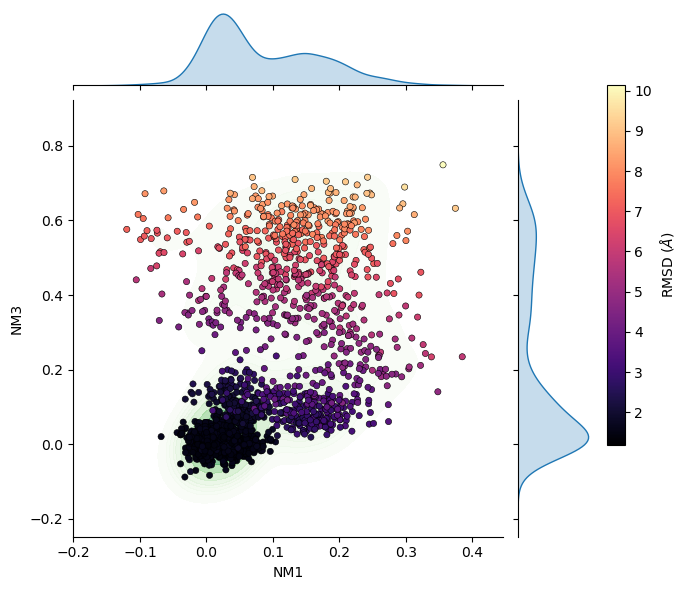

In [25]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Reactive distance 

In [38]:
from MDAnalysis.analysis import distances
u = mda.Universe("./ref_vis.pdb", "md_mol.xtc")

In [39]:
atom1 = u.select_atoms("id 5993")
atom2 = u.select_atoms("id 5946")

In [40]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumh_full_reactive_dist_rep0.npy", np.array(distanze))

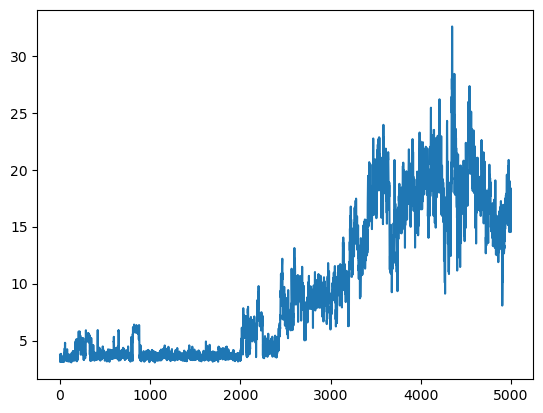

In [42]:
plt.plot(distanze)

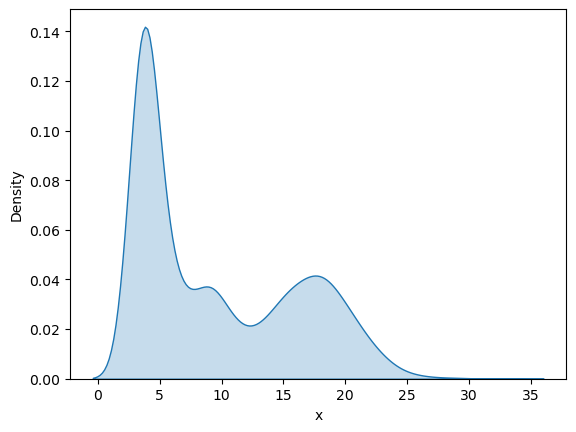

In [41]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

## Full complex  rep1

### Clamp motion

In [64]:
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [65]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [66]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

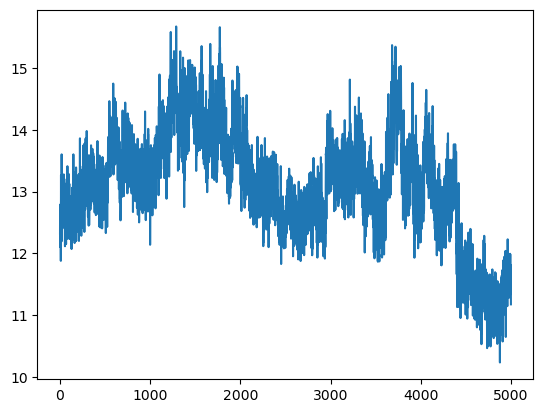

In [67]:
plt.plot(dist)

### Reactive distance 

In [33]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [34]:
atom1 = u.select_atoms("id 5993")
atom2 = u.select_atoms("id 5946")

In [35]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumh_full_reactive_dist_rep1.npy", np.array(distanze))

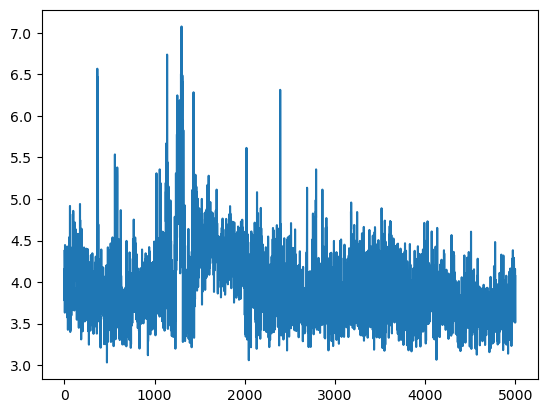

In [36]:
plt.plot(distanze)

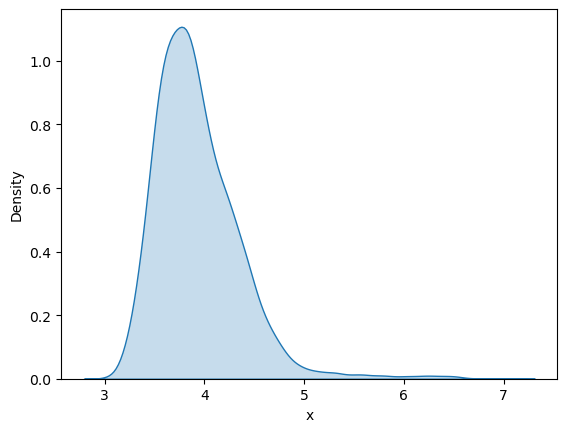

In [26]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

### ANM projection

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [30]:
structure = parsePDB('../PROD/ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.41 seconds.
@> 330.04 MB parsed at input rate 136.80 MB/s.
@> 5001 coordinate sets parsed at input rate 2072 frame/s.


In [31]:
dcd1.setCoords(structure)

In [32]:
dcd1.setAtoms(structure.calpha)

In [33]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [34]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [35]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [36]:
gumh_anm = loadModel(f"{root}/GlucTrans/GumH/Boltz1/free/exANM/gumh_exanm.exanm.npz")

In [37]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [38]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [39]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

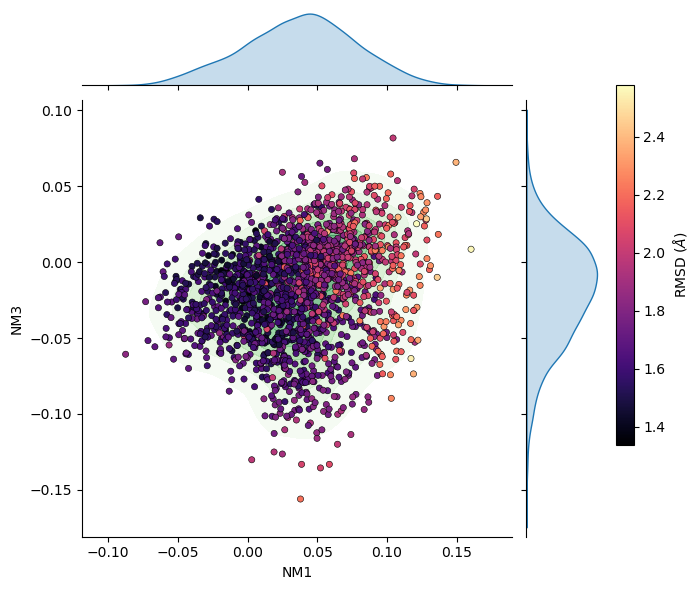

In [40]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Full complex  rep2

### Clamp motion

In [69]:
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [70]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [71]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

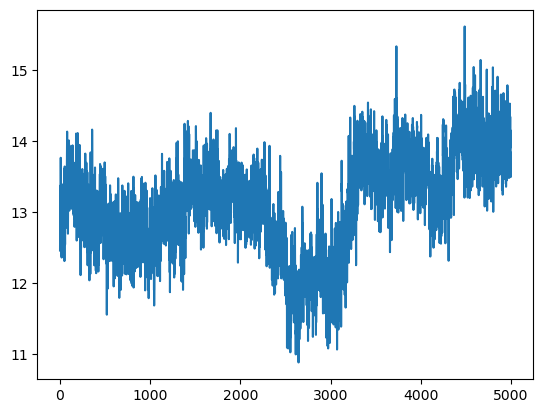

In [72]:
plt.plot(dist)

### Reactive distance 

In [44]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [45]:
atom1 = u.select_atoms("id 5993")
atom2 = u.select_atoms("id 5946")

In [46]:
distanze = []

for ts in u.trajectory:
    d = distances.dist(atom1, atom2, box=u.dimensions)[2]
    distanze.append(d[0])

np.save("gumh_full_reactive_dist_rep2.npy", np.array(distanze))

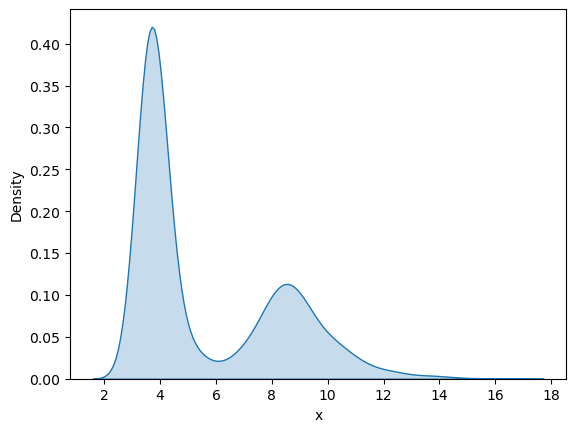

In [47]:
import seaborn as sns
sns.kdeplot(distanze, fill=True)
plt.xlabel("x")
plt.ylabel("Density")
plt.show()

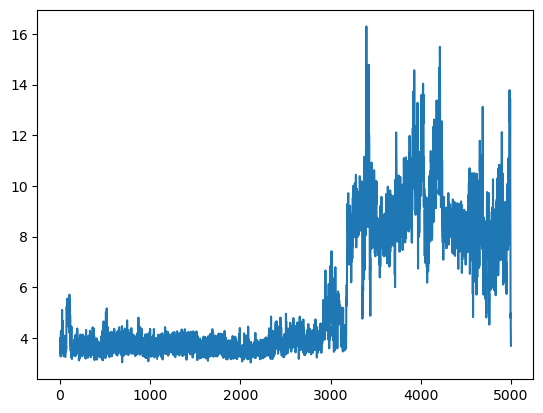

In [48]:
plt.plot(distanze)

### ANM projection

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [44]:
structure = parsePDB('../PROD/ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.46 seconds.
@> 330.04 MB parsed at input rate 134.43 MB/s.
@> 5001 coordinate sets parsed at input rate 2036 frame/s.


In [45]:
dcd1.setCoords(structure)

In [46]:
dcd1.setAtoms(structure.calpha)

In [47]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [48]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [49]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [50]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [51]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [52]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [53]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

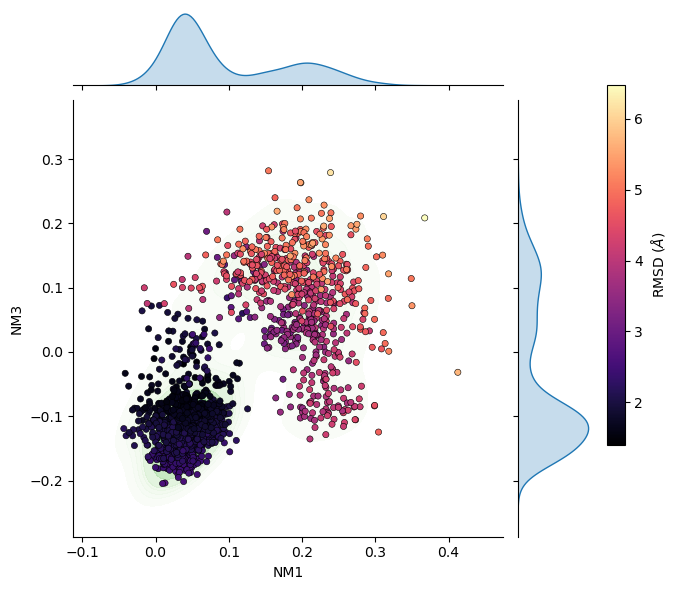

In [54]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


## Free model 0 


### ANM projection

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [75]:
structure = parsePDB('./ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 8.39 seconds.
@> 660.01 MB parsed at input rate 78.64 MB/s.
@> 10001 coordinate sets parsed at input rate 1191 frame/s.


In [76]:
dcd1.setCoords(structure)

In [77]:
dcd1.setAtoms(structure.calpha)

In [78]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [79]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [80]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [81]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [82]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [83]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [84]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

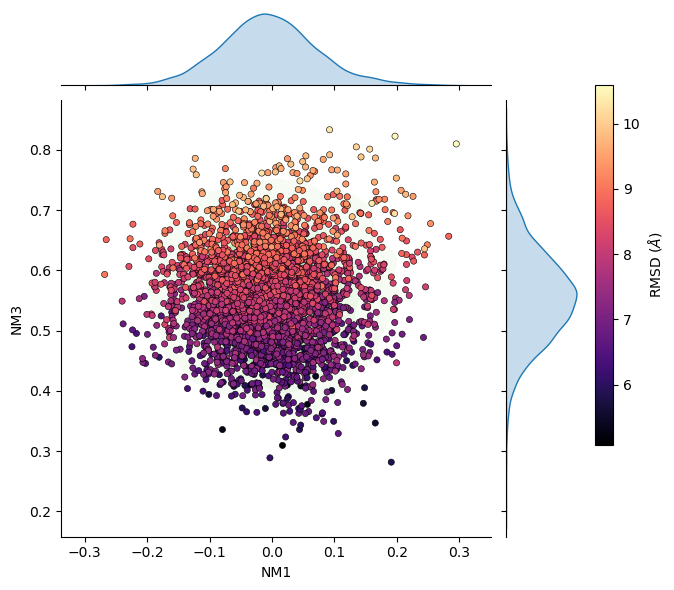

In [85]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)


scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [76]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:173 355:369 and name CA",
    "LINKER": "resid 174:190 338:354 and name CA",
    "C":      "resid 191:337 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "ref_prot.pdb"
traj = "ensemble.dcd"

rmsf_map = {}  

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


/home/davidelu/mambaforge/lib/python3.10/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


N: n_atoms=188  rmsf min/max=0.434/5.503
LINKER: n_atoms=34  rmsf min/max=0.392/1.409
C: n_atoms=147  rmsf min/max=0.339/2.303
TOTAL residues: 369 RMSF min/max: 0.33853853563439773 5.503185767889568
Saved intradomain_rmsf_CA.npz


### Clamp motion

In [5]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [12]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [13]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

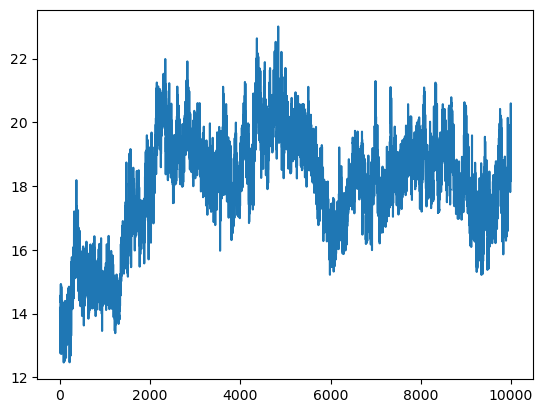

In [14]:
plt.plot(dist)

## Free model0 rep1



### ANM projection

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [8]:
structure = parsePDB('./ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.07s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 4.83 seconds.
@> 660.01 MB parsed at input rate 136.74 MB/s.
@> 10001 coordinate sets parsed at input rate 2072 frame/s.


In [9]:
dcd1.setCoords(structure)

In [10]:
dcd1.setAtoms(structure.calpha)

In [11]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.05s.


In [12]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [13]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [14]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [15]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [16]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [17]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

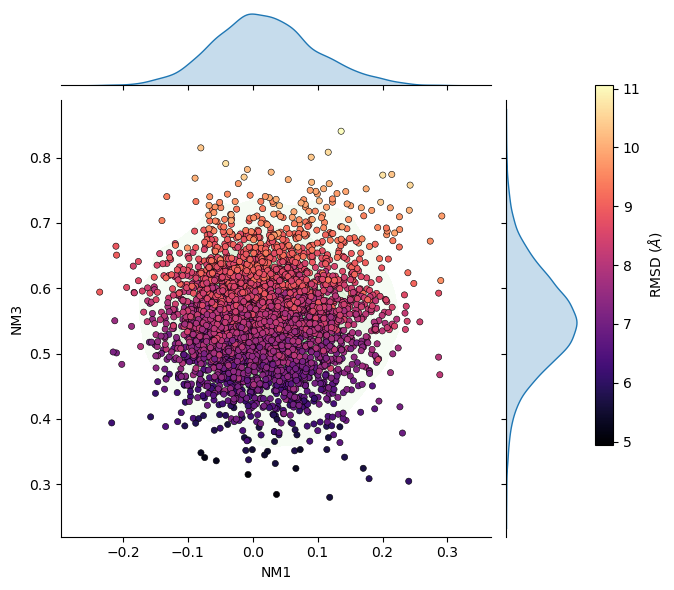

In [18]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Clamp motion

In [6]:
u = mda.Universe("../../PROD2/ref_vis.pdb", "md_mol.xtc")

In [7]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [8]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

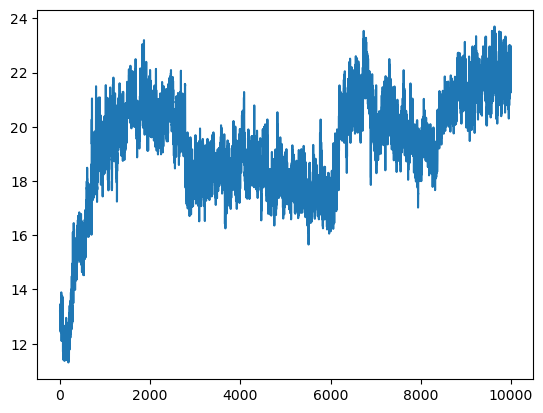

In [9]:
plt.plot(dist)

## Free model0 rep2



###  ANM projection

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [26]:
structure = parsePDB('../../PROD2/ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.13s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 7.39 seconds.
@> 660.01 MB parsed at input rate 89.28 MB/s.
@> 10001 coordinate sets parsed at input rate 1352 frame/s.


In [27]:
dcd1.setCoords(structure)

In [28]:
dcd1.setAtoms(structure.calpha)

In [29]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.05s.


In [30]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [31]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [32]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [33]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [34]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [35]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

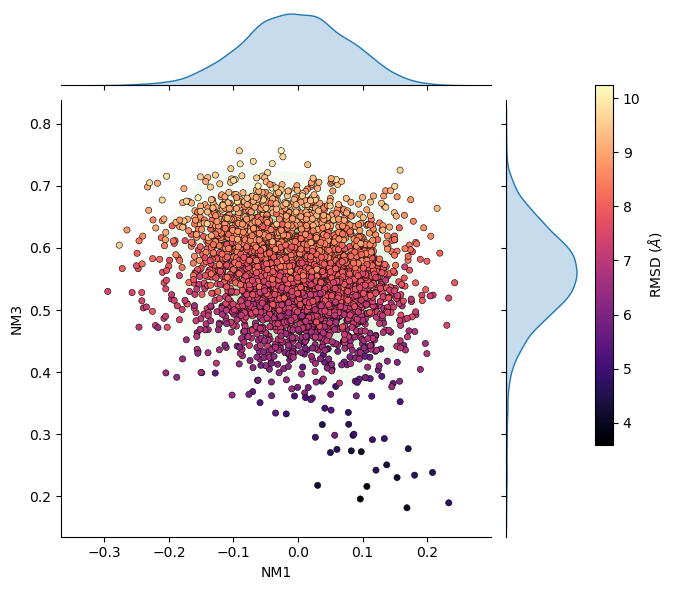

In [36]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Clamp motion

In [11]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [12]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [13]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

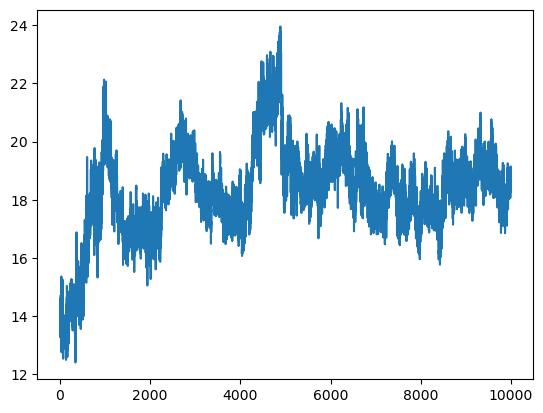

In [14]:
plt.plot(dist)

## Free conf0

###  ANM projection

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [40]:
structure = parsePDB('./ref_prot.pdb')
dcd1 = parseDCD('rep_0.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.67s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 43.00 seconds.
@> 660.01 MB parsed at input rate 15.35 MB/s.
@> 10001 coordinate sets parsed at input rate 232 frame/s.


In [41]:
dcd1.setCoords(structure)

In [42]:
dcd1.setAtoms(structure.calpha)

In [43]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.43s.


In [44]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [45]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [46]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [47]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [49]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [50]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

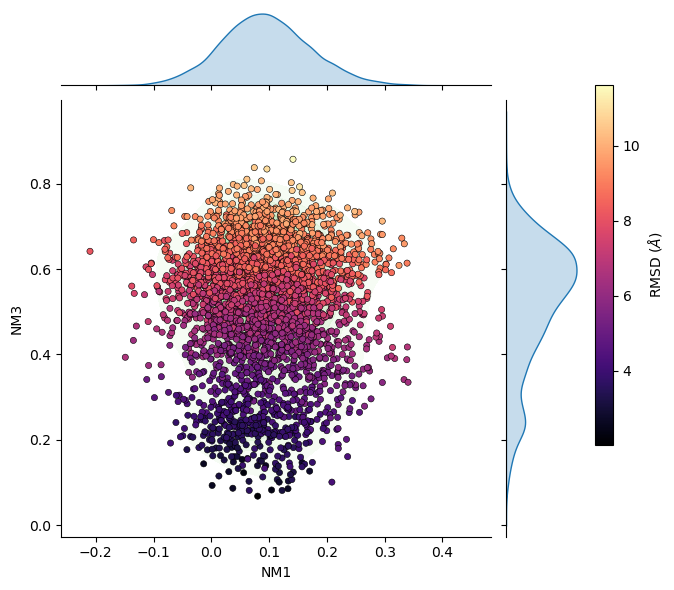

In [51]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [78]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:173 355:369 and name CA",
    "LINKER": "resid 174:190 338:354 and name CA",
    "C":      "resid 191:337 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "ref_prot.pdb"
traj = "rep_0.dcd"

rmsf_map = {} 

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


N: n_atoms=188  rmsf min/max=0.453/5.918
LINKER: n_atoms=34  rmsf min/max=0.446/1.713
C: n_atoms=147  rmsf min/max=0.366/2.323
TOTAL residues: 369 RMSF min/max: 0.3661166587985264 5.9182799546427285
Saved intradomain_rmsf_CA.npz


### Clamp motion

In [177]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [178]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [179]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

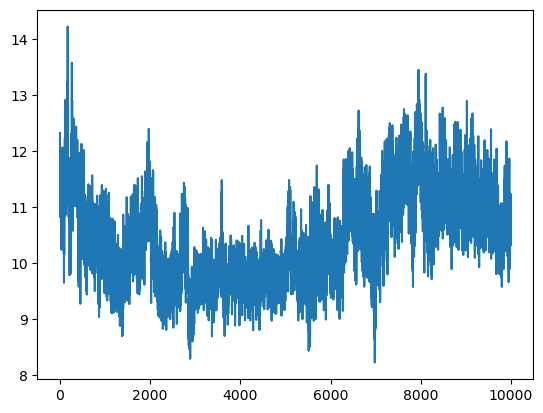

In [180]:
plt.plot(dist)

## Free conf0 Rep1

###  ANM projection

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [56]:
structure = parsePDB('../../rep_0/PROD2/ref_prot.pdb')
dcd2 = parseDCD('rep_1.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.68s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 34.56 seconds.
@> 660.01 MB parsed at input rate 19.10 MB/s.
@> 10001 coordinate sets parsed at input rate 289 frame/s.


In [57]:
dcd2.setCoords(structure)

In [58]:
dcd2.setAtoms(structure.calpha)

In [59]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.42s.


In [60]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd2])  

In [61]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [62]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [63]:
prj_anm= (1 / (dcd2.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [64]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd2])

In [65]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

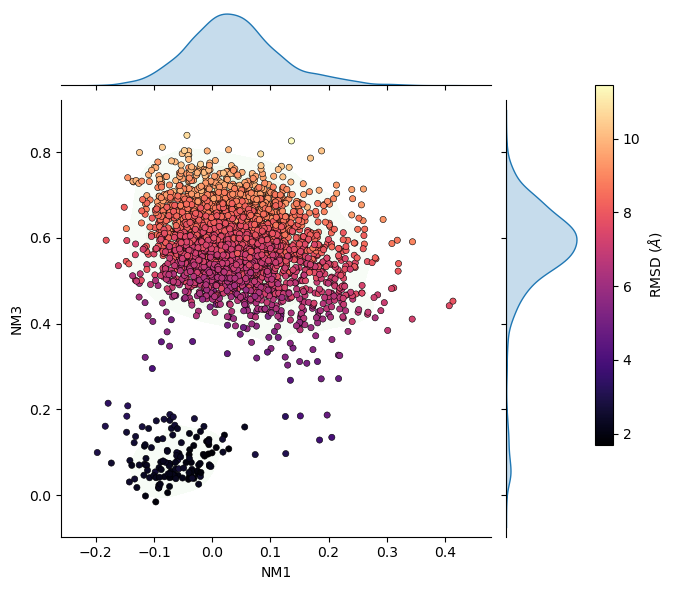

In [70]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [80]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:173 355:369 and name CA",
    "LINKER": "resid 174:190 338:354 and name CA",
    "C":      "resid 191:337 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "../../rep_0/PROD2/ref_prot.pdb"
traj = "rep_1.dcd"

rmsf_map = {} 

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


N: n_atoms=188  rmsf min/max=0.418/4.624
LINKER: n_atoms=34  rmsf min/max=0.468/1.644
C: n_atoms=147  rmsf min/max=0.328/1.475
TOTAL residues: 369 RMSF min/max: 0.3277911004521058 4.6236299604983655
Saved intradomain_rmsf_CA.npz


#### Clamp motion

In [157]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [158]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [159]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_closed1.npy", dist)

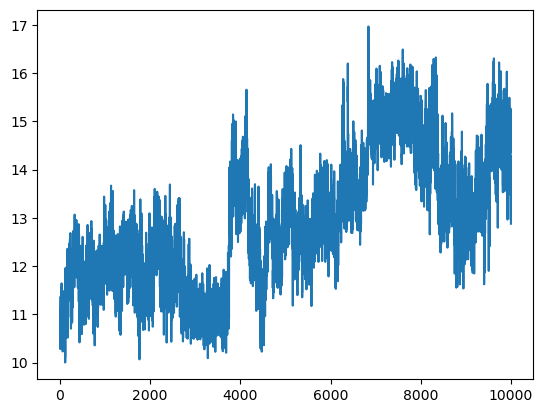

In [160]:
plt.plot(dist)

## Free conf0 Rep2

###  ANM projection

In [72]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [76]:
structure = parsePDB('../../rep_0/PROD2/ref_prot.pdb')
dcd3 = parseDCD('rep_2.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.57s.
@> DCD file contains 10001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 45.62 seconds.
@> 660.01 MB parsed at input rate 14.47 MB/s.
@> 10001 coordinate sets parsed at input rate 219 frame/s.


In [77]:
dcd3.setCoords(structure)

In [78]:
dcd3.setAtoms(structure.calpha)

In [79]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.47s.


In [80]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd3])  

In [81]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [82]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [83]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [84]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd3])

In [85]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

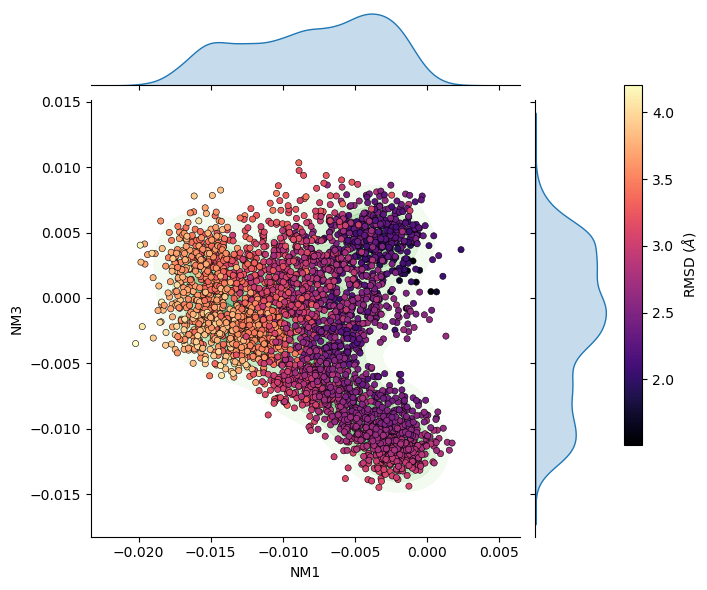

In [86]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)


scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


In [82]:
import MDAnalysis as mda
import numpy as np
from MDAnalysis.analysis import align, rms

DOMAINS = {
    "N":      "resid 1:173 355:369 and name CA",
    "LINKER": "resid 174:190 338:354 and name CA",
    "C":      "resid 191:337 and name CA",
}

def normalize_resname(r):
    r = str(r).upper()
    return "HIS" if r in ("HSD","HSE","HSP","HID","HIE","HIP") else r

top = "../../rep_0/PROD2/ref_prot.pdb"
traj = "rep_2.dcd"

rmsf_map = {}  

for name, sel in DOMAINS.items():

    u = mda.Universe(top, traj)


    align.AlignTraj(u, u, select=f"protein and ({sel})", in_memory=True).run()


    ca = u.select_atoms(sel)
    r = rms.RMSF(ca).run()
    vals = r.results.rmsf


    for atom, v in zip(ca, vals):
        key = (int(atom.resid), normalize_resname(atom.resname))

        rmsf_map.setdefault(key, float(v))

    print(f"{name}: n_atoms={ca.n_atoms}  rmsf min/max={vals.min():.3f}/{vals.max():.3f}")


keys_sorted = sorted(rmsf_map.keys(), key=lambda k: k[0])

resids   = np.array([k[0] for k in keys_sorted], dtype=int)
resnames = np.array([k[1] for k in keys_sorted])
rmsf_all = np.array([rmsf_map[k] for k in keys_sorted], dtype=float)

print("TOTAL residues:", len(resids), "RMSF min/max:", rmsf_all.min(), rmsf_all.max())

np.savez("intradomain_rmsf_CA.npz",
         resids=resids,
         resnames=resnames,
         rmsf=rmsf_all)

print("Saved intradomain_rmsf_CA.npz")


N: n_atoms=188  rmsf min/max=0.441/6.092
LINKER: n_atoms=34  rmsf min/max=0.412/1.641
C: n_atoms=147  rmsf min/max=0.359/1.532
TOTAL residues: 369 RMSF min/max: 0.35939200020056955 6.092417792809597
Saved intradomain_rmsf_CA.npz


### Clamp motion

In [36]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [37]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [38]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_closed1.npy", dist)

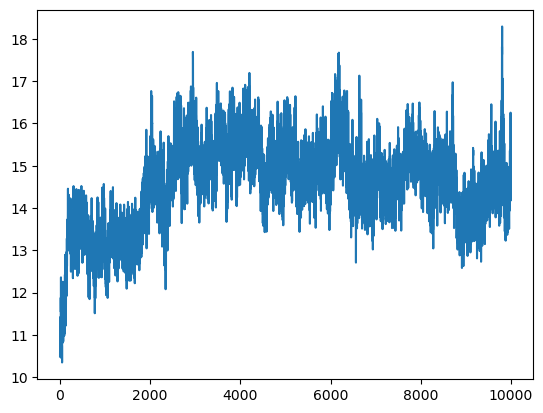

In [39]:
plt.plot(dist)

## Donor 


### Clamp motion

In [86]:
u = mda.Universe("ref_vis.pdb", "md_mol.xtc")

In [87]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [88]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

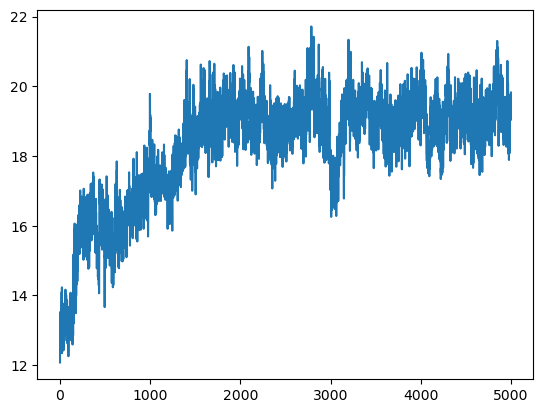

In [89]:
plt.plot(dist)

###  ANM projection

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [12]:
structure = parsePDB('./ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.11s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 3.34 seconds.
@> 330.04 MB parsed at input rate 98.83 MB/s.
@> 5001 coordinate sets parsed at input rate 1497 frame/s.


In [13]:
dcd1.setCoords(structure)

In [14]:
dcd1.setAtoms(structure.calpha)

In [15]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.04s.


In [16]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [17]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [18]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [19]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [20]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [21]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

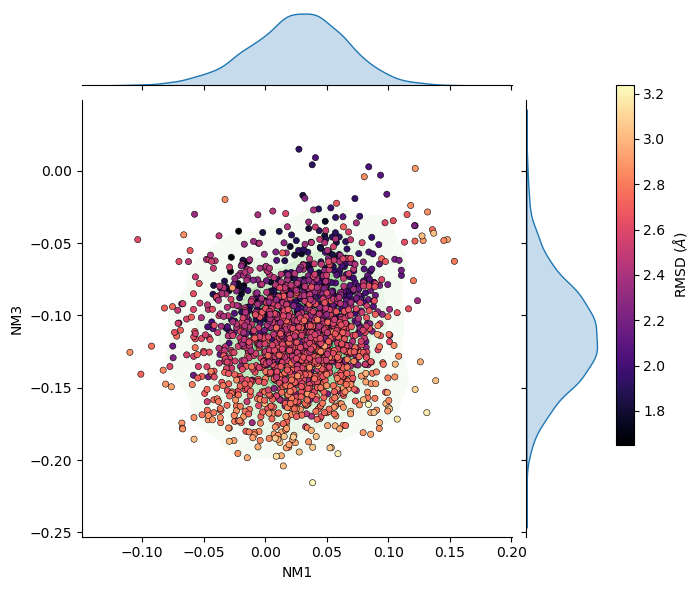

In [22]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Contacts

In [7]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [8]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [9]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

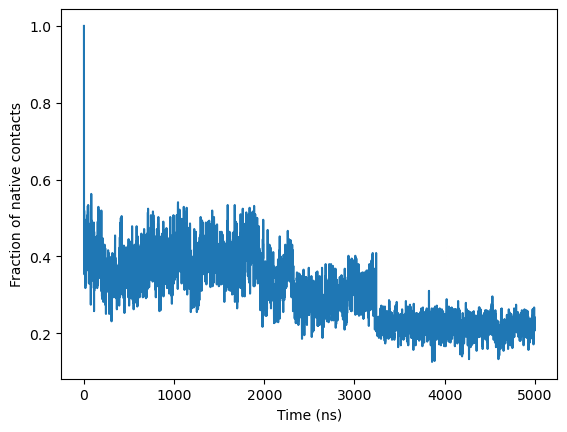

In [10]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()

## Donor  rep1

###  ANM projection

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [25]:
structure = parsePDB('../PROD/ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.09s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.39 seconds.
@> 330.04 MB parsed at input rate 138.18 MB/s.
@> 5001 coordinate sets parsed at input rate 2093 frame/s.


In [26]:
dcd1.setCoords(structure)

In [27]:
dcd1.setAtoms(structure.calpha)

In [28]:
ref_struct = parsePDB(f'sample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.05s.


In [29]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [30]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [31]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [32]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [33]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [34]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

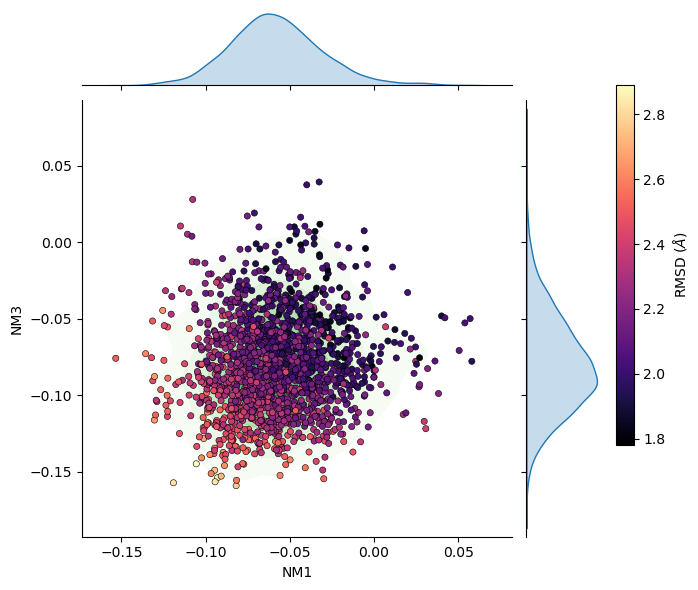

In [35]:

g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)



scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 


cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6]) 
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Clamp motion

In [94]:
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [95]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [96]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

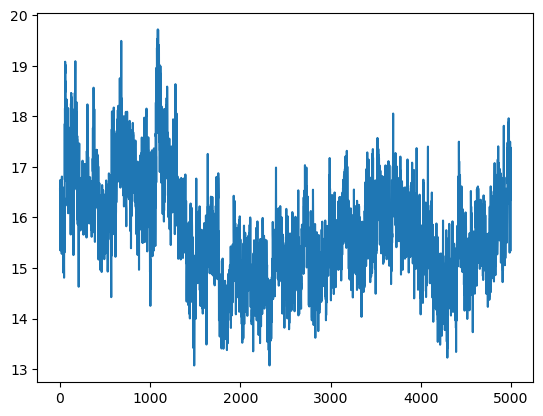

In [97]:
plt.plot(dist)

### Contacts

In [12]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [13]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [14]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

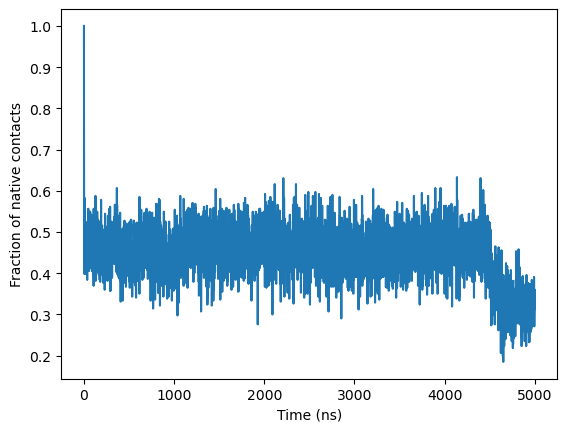

In [15]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()

## Donor  rep2

###  ANM projection

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
from prody import *
import seaborn as sns
plt.ion()

In [41]:
structure = parsePDB('../PROD/ref_prot.pdb')
dcd1 = parseDCD('ensemble.dcd')

@> 5760 atoms and 1 coordinate set(s) were parsed in 0.08s.
@> DCD file contains 5001 coordinate sets for 5760 atoms.
@> DCD file was parsed in 2.57 seconds.
@> 330.04 MB parsed at input rate 128.46 MB/s.
@> 5001 coordinate sets parsed at input rate 1946 frame/s.


In [42]:
dcd1.setCoords(structure)

In [43]:
dcd1.setAtoms(structure.calpha)

In [44]:
ref_struct = parsePDB(f'ample_998out.pdb')

@> 2884 atoms and 1 coordinate set(s) were parsed in 0.05s.


In [45]:
def_vec = np.array([frame.getCoords() - ref_struct.ca.getCoords() for frame in dcd1])  

In [46]:
def_vec = def_vec.reshape((def_vec.shape[0],def_vec.shape[1] * 3))

In [47]:
gumh_anm = loadModel(f"gumh_exanm.exanm.npz")

In [48]:
prj_anm= (1 / (dcd1.numAtoms()*0.5) ) * np.dot(def_vec,gumh_anm[:3].getArray() )

In [49]:
ensemble_rmsd=np.array([calcRMSD(ref_struct.ca.getCoords(), frame.getCoords()) for frame in dcd1])

In [50]:
df_nms = pd.DataFrame({'NM1': prj_anm[:,0], 'NM2': prj_anm[:,1],'NM3': prj_anm[:,2], 'RMSD': ensemble_rmsd})
df_nms.to_csv('all_replicas.csv', index=False)

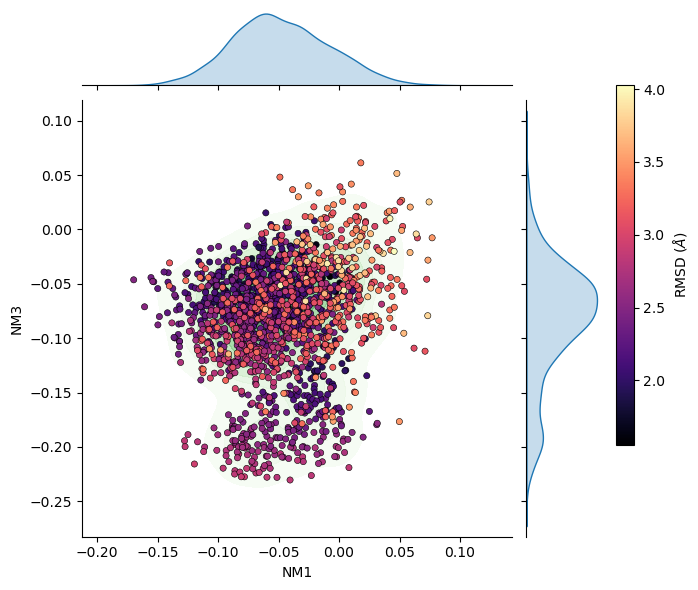

In [51]:
g = sns.jointplot(data=df_nms, x='NM1', y='NM3', kind="kde", fill=True, cmap="Greens", alpha=0.6)

scatter = g.ax_joint.scatter(df_nms['NM1'][::3], df_nms['NM3'][::3], c=df_nms['RMSD'][::3], cmap='magma', edgecolor='k', s=20, linewidth=0.4) 

cbar_ax = g.fig.add_axes([1.0, 0.25, 0.03, 0.6])  
cbar = g.fig.colorbar(scatter, cax=cbar_ax)
cbar.set_label(r'RMSD ($\AA$)')


### Clamp motion

In [99]:
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [100]:
g1 = u.select_atoms("id 1143")
g2 = u.select_atoms("id 2023")

In [101]:
dist = []

for ts in u.trajectory:
    dist.append(np.linalg.norm(g1.positions - g2.positions))

dist = np.array(dist)
np.save("dist_clamp_free.npy", dist)

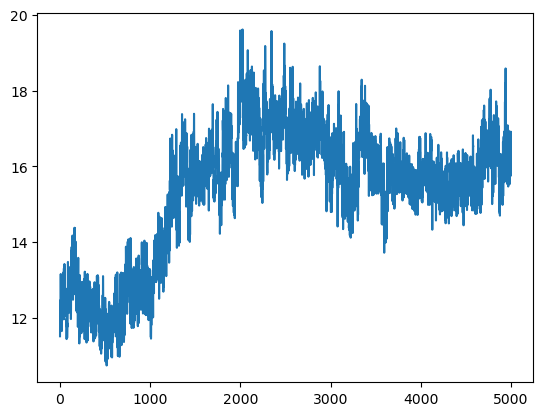

In [102]:
plt.plot(dist)

In [3]:
### Contacts

In [17]:
from MDAnalysis.analysis import distances
u = mda.Universe("../PROD/ref_vis.pdb", "md_mol.xtc")

In [18]:
protein = u.select_atoms("protein")
substrate = u.select_atoms("resname AMAN")

In [19]:
from MDAnalysis.analysis import contacts
ca = contacts.Contacts(
    u,
    select=(protein, substrate),
    refgroup=(protein, substrate),
    radius=4.5  # Å
)
ca.run()

Q = ca.results.timeseries[:,1]
np.save("native_contacts_Q_rep0.npy", Q)

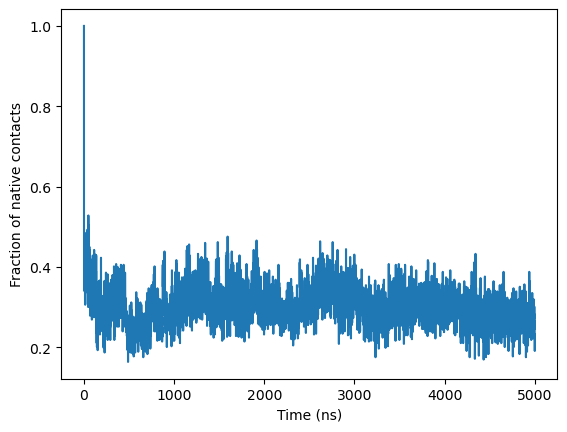

In [20]:
plt.plot( Q)  # ps → ns
plt.xlabel("Time (ns)")
plt.ylabel("Fraction of native contacts")
plt.show()